# Unsupervised Models — ELEC3612 Assignment 1

This notebook implements K-Means clustering on the dataset. The target 
variable is excluded during training and only used afterwards to evaluate 
cluster quality via external metrics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Load dataset
df = pd.read_csv('../data/aug_train.csv')
df = df.drop(columns=['enrollee_id'])

X = df.drop(columns=['target'])
y = df['target'].values

# Column types
numerical_cols = ['city_development_index', 'training_hours']
ordinal_cols = ['experience', 'last_new_job']
nominal_cols = ['city', 'gender', 'relevent_experience', 'enrolled_university',
                'education_level', 'major_discipline', 'company_size', 'company_type']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution: {np.unique(y, return_counts=True)}")

X shape: (19158, 12)
y shape: (19158,)

Class distribution: (array([0., 1.]), array([14381,  4777]))


## Preprocessing

We apply the same preprocessing pipeline as in the supervised models notebook.
Since clustering is unsupervised, we fit the preprocessor on the full dataset. There is no train/test split needed here.

In [2]:
# Build preprocessor
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('nom', nominal_pipeline, nominal_cols)
])

# Fit on full X — no train/test split for unsupervised learning
X_scaled = preprocessor.fit_transform(X)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"No missing values: {np.isnan(X_scaled).sum() == 0}")

X_scaled shape: (19158, 160)
No missing values: True


## K-Means Clustering

We set k=2 to match the number of known classes in the dataset. 
Cluster quality is evaluated using Silhouette Score (internal validation), 
ARI and AMI (external validation, using the true labels).

In [3]:
# Number of clusters = number of classes
k = len(np.unique(y))
print(f"Number of clusters: {k}")

# K-Means
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
sil = silhouette_score(X_scaled, labels)
ari = adjusted_rand_score(y, labels)
ami = adjusted_mutual_info_score(y, labels)

print(f"\nSilhouette Score : {sil:.4f}")
print(f"ARI              : {ari:.4f}")
print(f"AMI              : {ami:.4f}")

Number of clusters: 2

Silhouette Score : 0.5277
ARI              : -0.0180
AMI              : 0.0034


## Elbow Method

We use the elbow method to verify that k=2 is a reasonable choice 
for the number of clusters.

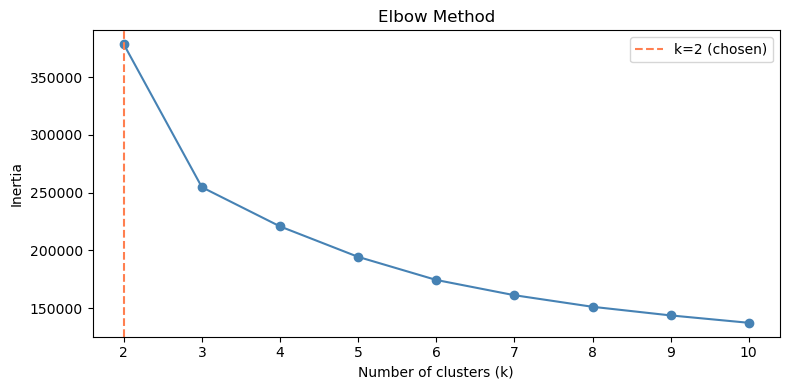

In [4]:
# Elbow method to verify k selection
inertias = []
k_range = range(2, 11)

for k_val in k_range:
    km = KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.axvline(x=2, color='coral', linestyle='--', label='k=2 (chosen)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.legend()
plt.tight_layout()
plt.show()